In [3]:
import ssl
import nltk

# Solución temporal para que NLTK pueda descargar sus recursos
ssl._create_default_https_context = ssl._create_unverified_context

nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/josetanchezz/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/josetanchezz/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
import pandas as pd

RUTA_DATASET = "gutenberg_novels_dataset.csv"

# Cargar dataset
df = pd.read_csv(RUTA_DATASET)

# Verificar libros incluidos
display(df[["gutenberg_id", "title", "author", "text_length"]])

# Metadatos históricos para el reporte
informacion_libros = pd.DataFrame({
    "Título": [
        "Pride and Prejudice",
        "Frankenstein; or, The Modern Prometheus",
        "Dracula"
    ],
    "Autor(a)": [
        "Jane Austen",
        "Mary Shelley",
        "Bram Stoker"
    ],
    "Año / época aproximada de publicación": [
        "1813 — Inglaterra, época georgiana / Regencia",
        "1818 — Romanticismo inglés (edición revisada: 1831)",
        "1897 — Final de la época victoriana"
    ]
})

display(informacion_libros)

,gutenberg_id,title,author,text_length
0,1342,Pride and Prejudice,Jane Austen,728392
1,84,Frankenstein,Mary Shelley,419290
2,345,Dracula,Bram Stoker,845805


,Título,Autor(a),Año / época aproximada de publicación
0,Pride and Prejudice,Jane Austen,"1813 — Inglaterra, época georgiana / Regencia"
1,"Frankenstein; or, The Modern Prometheus",Mary Shelley,1818 — Romanticismo inglés (edición revisada: ...
2,Dracula,Bram Stoker,1897 — Final de la época victoriana


In [5]:
import random
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize

# Descargar recurso de NLTK para segmentar oraciones
nltk.download("punkt")
nltk.download("punkt_tab")  # Necesario en versiones recientes de NLTK

SEMILLA = 42
TAMANO_MUESTRA = 100

def limpiar_texto_gutenberg(texto):
    """
    Elimina, cuando están presentes, las cabeceras y notas finales
    añadidas por Project Gutenberg. Así los conteos representan
    principalmente el contenido de la novela.
    """
    inicio = texto.find("*** START OF")
    if inicio != -1:
        salto_linea = texto.find("\n", inicio)
        texto = texto[salto_linea:].strip()

    fin = texto.find("*** END OF")
    if fin != -1:
        texto = texto[:fin].strip()

    return texto

resultados = []
muestras = {}

for _, fila in df.iterrows():
    titulo = fila["title"]
    texto_limpio = limpiar_texto_gutenberg(fila["text"])

    # Segmentación en oraciones
    oraciones = sent_tokenize(texto_limpio)

    # Tokenización de todo el libro
    tokens_libro = word_tokenize(texto_limpio)

    # Muestra aleatoria reproducible de 100 oraciones
    generador = random.Random(SEMILLA)
    muestra_oraciones = generador.sample(
        oraciones,
        k=min(TAMANO_MUESTRA, len(oraciones))
    )

    # Tokenización de la muestra
    tokens_muestra = [
        token
        for oracion in muestra_oraciones
        for token in word_tokenize(oracion)
    ]

    # Guardar la muestra: se utilizará en las secciones 2 y 3
    muestras[titulo] = {
        "oraciones": muestra_oraciones,
        "tokens": tokens_muestra
    }

    resultados.append({
        "Libro": titulo,
        "Total de oraciones": len(oraciones),
        "Total de tokens": len(tokens_libro),
        "Oraciones en la muestra": len(muestra_oraciones),
        "Tokens en la muestra": len(tokens_muestra)
    })

tabla_comparativa = pd.DataFrame(resultados)
display(tabla_comparativa)

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/josetanchezz/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/josetanchezz/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,Libro,Total de oraciones,Total de tokens,Oraciones en la muestra,Tokens en la muestra
0,Pride and Prejudice,6140,152022,100,2552
1,Frankenstein,3315,85708,100,2347
2,Dracula,8497,191692,100,2083


In [7]:
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

# Cargar modelo preentrenado de spaCy para inglés
nlp = spacy.load("en_core_web_sm")

# Diccionarios donde se almacenarán los resultados
documentos_muestra = {}
conteos_pos = {}
tokens_etiquetados = []

# Etiquetar las 100 oraciones de muestra de cada novela
for libro, datos in muestras.items():

    # Procesar las oraciones mediante spaCy
    docs = list(nlp.pipe(datos["oraciones"]))

    documentos_muestra[libro] = docs

    # Se excluyen espacios; se conservan palabras y puntuación
    tokens = [
        token
        for doc in docs
        for token in doc
        if not token.is_space
    ]

    # Conteo de categorías POS universales de spaCy
    conteos_pos[libro] = Counter(token.pos_ for token in tokens)

    # Guardar token, etiqueta POS y contexto para análisis posterior
    for doc in docs:
        for token in doc:
            if not token.is_space:
                tokens_etiquetados.append({
                    "Libro": libro,
                    "Token": token.text,
                    "Token_normalizado": token.text.lower(),
                    "POS_universal": token.pos_,
                    "POS_fino_Penn": token.tag_,
                    "Contexto": doc.text
                })

df_tokens_pos = pd.DataFrame(tokens_etiquetados)

print("Etiquetado POS completado.")
display(df_tokens_pos.head(15))

Matplotlib is building the font cache; this may take a moment.


Etiquetado POS completado.


,Libro,Token,Token_normalizado,POS_universal,POS_fino_Penn,Contexto
0,Pride and Prejudice,We,we,PRON,PRP,We want none of them;\ndo we?”
1,Pride and Prejudice,want,want,VERB,VBP,We want none of them;\ndo we?”
2,Pride and Prejudice,none,none,NOUN,NN,We want none of them;\ndo we?”
3,Pride and Prejudice,of,of,ADP,IN,We want none of them;\ndo we?”
4,Pride and Prejudice,them,them,PRON,PRP,We want none of them;\ndo we?”
5,Pride and Prejudice,;,;,PUNCT,:,We want none of them;\ndo we?”
6,Pride and Prejudice,do,do,VERB,VBP,We want none of them;\ndo we?”
7,Pride and Prejudice,we,we,PRON,PRP,We want none of them;\ndo we?”
8,Pride and Prejudice,?,?,PUNCT,.,We want none of them;\ndo we?”
9,Pride and Prejudice,”,”,PUNCT,'',We want none of them;\ndo we?”


In [8]:
# Convertir los conteos a una tabla: fila = libro, columna = categoría POS
tabla_pos = (
    pd.DataFrame(conteos_pos)
    .T
    .fillna(0)
    .astype(int)
)

# Ordenar columnas según las etiquetas universales más comunes
orden_pos = [
    "NOUN", "PROPN", "VERB", "AUX", "ADJ", "ADV",
    "PRON", "DET", "ADP", "CCONJ", "SCONJ",
    "PART", "NUM", "INTJ", "PUNCT", "SPACE", "X"
]

tabla_pos = tabla_pos.reindex(
    columns=[pos for pos in orden_pos if pos in tabla_pos.columns],
    fill_value=0
)

display(tabla_pos)

,NOUN,PROPN,VERB,AUX,ADJ,ADV,PRON,DET,ADP,CCONJ,SCONJ,PART,NUM,INTJ,PUNCT,X
Pride and Prejudice,318,114,263,176,136,146,338,164,262,90,64,76,13,9,383,3
Frankenstein,392,48,285,114,146,99,303,208,225,108,55,47,10,6,308,0
Dracula,252,61,250,122,116,127,305,131,170,90,70,48,6,3,328,0


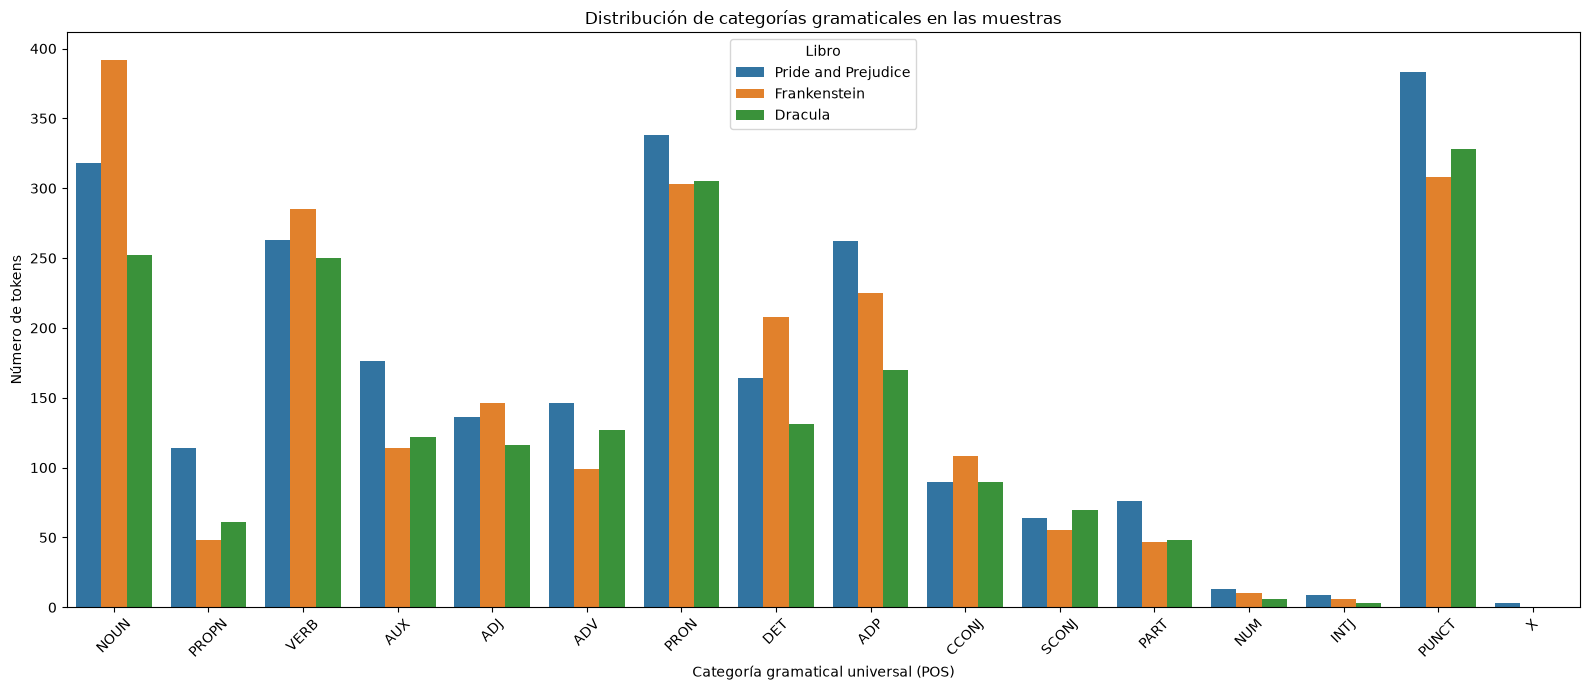

In [9]:
tabla_pos_grafico = tabla_pos.reset_index(names="Libro").melt(
    id_vars="Libro",
    var_name="Categoría POS",
    value_name="Frecuencia"
)

plt.figure(figsize=(16, 7))

sns.barplot(
    data=tabla_pos_grafico,
    x="Categoría POS",
    y="Frecuencia",
    hue="Libro"
)

plt.title("Distribución de categorías gramaticales en las muestras")
plt.xlabel("Categoría gramatical universal (POS)")
plt.ylabel("Número de tokens")
plt.xticks(rotation=45)
plt.legend(title="Libro")
plt.tight_layout()
plt.show()

In [10]:
# Agrupar por palabra y obtener las etiquetas POS distintas que recibió
ambiguedades = (
    df_tokens_pos[
        # Se consideran solo palabras alfabéticas y se descarta puntuación
        df_tokens_pos["Token_normalizado"].str.isalpha()
    ]
    .groupby("Token_normalizado")
    .agg(
        etiquetas_POS=("POS_universal", lambda x: sorted(set(x))),
        numero_etiquetas=("POS_universal", "nunique"),
        frecuencia=("POS_universal", "size")
    )
    .reset_index()
)

# Palabras con al menos dos etiquetas y al menos tres apariciones
ambiguedades = ambiguedades[
    (ambiguedades["numero_etiquetas"] >= 2) &
    (ambiguedades["frecuencia"] >= 3)
].sort_values(
    by=["numero_etiquetas", "frecuencia"],
    ascending=False
)

print("Palabras ambiguas detectadas:")
display(ambiguedades.head(15))

# Seleccionar las primeras 3 palabras ambiguas encontradas
tres_ambiguas = ambiguedades.head(3)["Token_normalizado"].tolist()

for palabra in tres_ambiguas:
    print(f"\n{'=' * 100}")
    print(f"PALABRA AMBIGUA: '{palabra}'")

    ejemplos = (
        df_tokens_pos[df_tokens_pos["Token_normalizado"] == palabra]
        [["Libro", "Token", "POS_universal", "POS_fino_Penn", "Contexto"]]
        .drop_duplicates()
        .head(6)
    )

    display(ejemplos)

Palabras ambiguas detectadas:


,Token_normalizado,etiquetas_POS,numero_etiquetas,frecuencia
970,no,"[ADV, DET, INTJ, PRON]",4,19
1454,that,"[DET, PRON, SCONJ]",3,68
95,as,"[ADP, ADV, SCONJ]",3,47
49,all,"[ADV, DET, PRON]",3,36
141,before,"[ADP, ADV, SCONJ]",3,11
243,close,"[ADJ, ADV, VERB]",3,3
441,either,"[ADV, CCONJ, PRON]",3,3
634,half,"[ADV, DET, NOUN]",3,3
704,i,"[NOUN, PRON]",2,184
992,of,"[ADP, NOUN]",2,167



PALABRA AMBIGUA: 'no'


,Libro,Token,POS_universal,POS_fino_Penn,Contexto
377,Pride and Prejudice,no,DET,DT,Bingley urged Mr. Jones’s being sent for\nimme...
436,Pride and Prejudice,no,ADV,RB,[Illustration]\n\nMr. Collins was not left lon...
546,Pride and Prejudice,No,PRON,DT,"“No more have I,” said Mr. Bennet; “and I am g..."
689,Pride and Prejudice,no,INTJ,UH,"“Oh no, my regret and compassion are all done ..."
761,Pride and Prejudice,no,DET,DT,She\nmust own that she was tired of great hous...
992,Pride and Prejudice,no,INTJ,UH,At present I am not in love with\nMr. Wickham;...



PALABRA AMBIGUA: 'that'


,Libro,Token,POS_universal,POS_fino_Penn,Contexto
120,Pride and Prejudice,that,SCONJ,IN,Do you think it incredible\nthat Mr. Collins s...
198,Pride and Prejudice,that,PRON,WDT,"For\nmy part, Mr. Bingley, _I_ always keep ser..."
241,Pride and Prejudice,that,PRON,WDT,Mrs. Gardiner went away in all the perplexity ...
246,Pride and Prejudice,that,DET,DT,Mrs. Gardiner went away in all the perplexity ...
278,Pride and Prejudice,that,SCONJ,IN,"However, I recollected afterwards, that if he ..."
348,Pride and Prejudice,that,PRON,DT,“I am sorry to hear _that_; but why did you no...



PALABRA AMBIGUA: 'as'


,Libro,Token,POS_universal,POS_fino_Penn,Contexto
140,Pride and Prejudice,as,SCONJ,IN,Do you think it incredible\nthat Mr. Collins s...
302,Pride and Prejudice,as,ADP,IN,"However, I recollected afterwards, that if he ..."
715,Pride and Prejudice,as,SCONJ,IN,Mr. Bennet raised his eyes from his book as sh...
913,Pride and Prejudice,as,ADV,RB,"On the contrary, every particular\nrelative to..."
915,Pride and Prejudice,as,ADP,IN,"On the contrary, every particular\nrelative to..."
1085,Pride and Prejudice,as,ADP,IN,"But, perhaps, Mr. Bingley did\nnot take the ho..."


In [11]:
LIBRO_SELECCIONADO = "Pride and Prejudice"

# Reunir todos los tokens de la muestra ya etiquetada en la Sección 2
tokens_libro = df_tokens_pos[
    df_tokens_pos["Libro"] == LIBRO_SELECCIONADO
].copy()

# Conservar palabras; se excluye puntuación para que los ejemplos sean útiles
diez_tokens = (
    tokens_libro[
        tokens_libro["Token_normalizado"].str.isalpha()
    ]
    [["Token", "POS_universal", "POS_fino_Penn", "Contexto"]]
    .drop_duplicates(subset=["Token", "POS_universal", "POS_fino_Penn"])
    .head(10)
    .reset_index(drop=True)
)

print(f"Libro elegido: {LIBRO_SELECCIONADO}")
display(diez_tokens)

Libro elegido: Pride and Prejudice


,Token,POS_universal,POS_fino_Penn,Contexto
0,We,PRON,PRP,We want none of them;\ndo we?”
1,want,VERB,VBP,We want none of them;\ndo we?”
2,none,NOUN,NN,We want none of them;\ndo we?”
3,of,ADP,IN,We want none of them;\ndo we?”
4,them,PRON,PRP,We want none of them;\ndo we?”
5,do,VERB,VBP,We want none of them;\ndo we?”
6,we,PRON,PRP,We want none of them;\ndo we?”
7,Do,VERB,VBP,"Do not you, Darcy?”"
8,not,PART,RB,"Do not you, Darcy?”"
9,you,PRON,PRP,"Do not you, Darcy?”"


In [12]:
diccionario_penn = {
    "CC": "Conjunción coordinante",
    "CD": "Número cardinal",
    "DT": "Determinante",
    "EX": "Existencial there",
    "FW": "Palabra extranjera",
    "IN": "Preposición o conjunción subordinante",
    "JJ": "Adjetivo",
    "JJR": "Adjetivo comparativo",
    "JJS": "Adjetivo superlativo",
    "LS": "Marcador de lista",
    "MD": "Verbo modal",
    "NN": "Sustantivo singular o masivo",
    "NNS": "Sustantivo plural",
    "NNP": "Nombre propio singular",
    "NNPS": "Nombre propio plural",
    "PDT": "Predeterminante",
    "POS": "Posesivo",
    "PRP": "Pronombre personal",
    "PRP$": "Pronombre posesivo",
    "RB": "Adverbio",
    "RBR": "Adverbio comparativo",
    "RBS": "Adverbio superlativo",
    "RP": "Partícula",
    "SYM": "Símbolo",
    "TO": "to",
    "UH": "Interjección",
    "VB": "Verbo en forma base",
    "VBD": "Verbo en pasado",
    "VBG": "Verbo en gerundio o participio presente",
    "VBN": "Verbo en participio pasado",
    "VBP": "Verbo presente no tercera persona",
    "VBZ": "Verbo presente tercera persona",
    "WDT": "Determinante interrogativo",
    "WP": "Pronombre interrogativo",
    "WP$": "Pronombre posesivo interrogativo",
    "WRB": "Adverbio interrogativo"
}

diez_tokens["Significado etiqueta Penn"] = diez_tokens["POS_fino_Penn"].map(diccionario_penn)
display(diez_tokens[[
    "Token", "POS_universal",
    "POS_fino_Penn", "Significado etiqueta Penn"
]])

,Token,POS_universal,POS_fino_Penn,Significado etiqueta Penn
0,We,PRON,PRP,Pronombre personal
1,want,VERB,VBP,Verbo presente no tercera persona
2,none,NOUN,NN,Sustantivo singular o masivo
3,of,ADP,IN,Preposición o conjunción subordinante
4,them,PRON,PRP,Pronombre personal
5,do,VERB,VBP,Verbo presente no tercera persona
6,we,PRON,PRP,Pronombre personal
7,Do,VERB,VBP,Verbo presente no tercera persona
8,not,PART,RB,Adverbio
9,you,PRON,PRP,Pronombre personal


In [13]:
# Elegir cinco oraciones consecutivas de la muestra
INDICE_INICIAL = 0  # Puedes cambiarlo, por ejemplo, a 10 o 20

cinco_oraciones = muestras[LIBRO_SELECCIONADO]["oraciones"][
    INDICE_INICIAL:INDICE_INICIAL + 5
]

docs_cinco_oraciones = list(nlp.pipe(cinco_oraciones))

for numero, doc in enumerate(docs_cinco_oraciones, start=1):
    print(f"\n{'=' * 100}")
    print(f"ORACIÓN {numero}:")
    print(doc.text)

    tabla_modelo = pd.DataFrame({
        "Token": [token.text for token in doc],
        "Etiqueta del modelo (Penn)": [token.tag_ for token in doc],
        "POS universal del modelo": [token.pos_ for token in doc]
    })

    display(tabla_modelo)


ORACIÓN 1:
We want none of them;
do we?”


,Token,Etiqueta del modelo (Penn),POS universal del modelo
0,We,PRP,PRON
1,want,VBP,VERB
2,none,NN,NOUN
3,of,IN,ADP
4,them,PRP,PRON
5,;,:,PUNCT
6,\n,_SP,SPACE
7,do,VBP,VERB
8,we,PRP,PRON
9,?,.,PUNCT



ORACIÓN 2:
Do not you, Darcy?”


,Token,Etiqueta del modelo (Penn),POS universal del modelo
0,Do,VBP,VERB
1,not,RB,PART
2,you,PRP,PRON
3,",",",",PUNCT
4,Darcy,NNP,PROPN
5,?,.,PUNCT
6,”,'',PUNCT



ORACIÓN 3:
When she was discontented, she
fancied herself nervous.


,Token,Etiqueta del modelo (Penn),POS universal del modelo
0,When,WRB,SCONJ
1,she,PRP,PRON
2,was,VBD,AUX
3,discontented,VBN,VERB
4,",",",",PUNCT
5,she,PRP,PRON
6,\n,_SP,SPACE
7,fancied,VBD,VERB
8,herself,PRP,PRON
9,nervous,JJ,ADJ



ORACIÓN 4:
Mr. Darcy’s letter to Lady Catherine was in a different style, and still
different from either was what Mr. Bennet sent to Mr. Collins, in return
for his last.


,Token,Etiqueta del modelo (Penn),POS universal del modelo
0,Mr.,NNP,PROPN
1,Darcy,NNP,PROPN
2,’s,POS,PART
3,letter,NN,NOUN
4,to,IN,ADP
5,Lady,NNP,PROPN
6,Catherine,NNP,PROPN
7,was,VBD,AUX
8,in,IN,ADP
9,a,DT,DET



ORACIÓN 5:
They had, therefore, many
acquaintance in common; and, though Wickham had been little there since
the death of Darcy’s father, five years before, it was yet in his power
to give her fresher intelligence of her former friends than she had been
in the way of procuring.


,Token,Etiqueta del modelo (Penn),POS universal del modelo
0,They,PRP,PRON
1,had,VBD,AUX
2,",",",",PUNCT
3,therefore,RB,ADV
4,",",",",PUNCT
5,many,JJ,ADJ
6,\n,_SP,SPACE
7,acquaintance,NN,NOUN
8,in,IN,ADP
9,common,JJ,ADJ


In [14]:
etiquetas_manuales = {
    # Oración 1:
    # We want none of them;\ndo we?”
    1: [
        "PRP", "VBP", "NN", "IN", "PRP",
        ":", "_SP", "VBP", "PRP", ".", "''"
    ],

    # Oración 2:
    # Do not you, Darcy?”
    2: [
        "VBP", "RB", "PRP", ",", "NNP", ".", "''"
    ],

    # Oración 3:
    # When she was discontented, she\nfancied herself nervous.
    3: [
        "WRB", "PRP", "VBD", "VBN", ",", "PRP",
        "_SP", "VBD", "PRP", "JJ", "."
    ],

    # Oración 4:
    # Mr. Darcy’s letter to Lady Catherine was in a different style, and still
    # different from either was what Mr. Bennet sent to Mr. Collins, in return
    # for his last.
    4: [
        "NNP", "NNP", "POS", "NN", "IN", "NNP", "NNP",
        "VBD", "IN", "DT", "JJ", "NN", ",", "CC", "RB",
        "_SP", "JJ", "IN", "DT", "VBD", "WP", "NNP", "NNP",
        "VBD", "IN", "NNP", "NNP", ",", "IN", "NN", "_SP",
        "IN", "PRP$", "JJ", "."
    ],

    # Oración 5:
    # They had, therefore, many acquaintance in common; and, though Wickham...
    5: [
        "PRP", "VBD", ",", "RB", ",", "JJ", "_SP",
        "NN", "IN", "JJ", ":", "CC", ",", "IN", "NNP",
        "VBD", "VBN", "JJ", "RB", "IN", "_SP", "DT", "NN",
        "IN", "NNP", "POS", "NN", ",", "CD", "NNS", "RB", ",",
        "PRP", "VBD", "RB", "IN", "PRP$", "NN", "_SP", "TO",
        "VB", "PRP", "JJR", "NN", "IN", "PRP$", "JJ", "NNS",
        "IN", "PRP", "VBD", "VBN", "_SP", "IN", "DT", "NN",
        "IN", "VBG", "."
    ]
}

In [15]:
comparaciones = []

for numero, doc in enumerate(docs_cinco_oraciones, start=1):
    tokens = [token.text for token in doc]
    etiquetas_modelo = [token.tag_ for token in doc]
    etiquetas_humano = etiquetas_manuales[numero]

    if len(tokens) != len(etiquetas_humano):
        print(
            f"Oración {numero}: hay {len(tokens)} tokens, pero "
            f"se ingresaron {len(etiquetas_humano)} etiquetas manuales."
        )
        continue

    for token, etiqueta_modelo, etiqueta_humana in zip(
        tokens, etiquetas_modelo, etiquetas_humano
    ):
        comparaciones.append({
            "Oración": numero,
            "Token": token,
            "Etiqueta manual (Penn)": etiqueta_humana,
            "Etiqueta modelo (Penn)": etiqueta_modelo,
            "¿Coinciden?": etiqueta_humana == etiqueta_modelo
        })

df_comparacion_manual = pd.DataFrame(comparaciones)

display(df_comparacion_manual)

if not df_comparacion_manual.empty:
    porcentaje_coincidencia = (
        df_comparacion_manual["¿Coinciden?"].mean() * 100
    )

    print(
        f"Coincidencia entre anotación manual y modelo: "
        f"{porcentaje_coincidencia:.2f}%"
    )

    print("\nDesacuerdos:")
    display(
        df_comparacion_manual[
            ~df_comparacion_manual["¿Coinciden?"]
        ]
    )

,Oración,Token,Etiqueta manual (Penn),Etiqueta modelo (Penn),¿Coinciden?
0,1,We,PRP,PRP,True
1,1,want,VBP,VBP,True
2,1,none,NN,NN,True
3,1,of,IN,IN,True
4,1,them,PRP,PRP,True
...,...,...,...,...,...
118,5,the,DT,DT,True
119,5,way,NN,NN,True
120,5,of,IN,IN,True
121,5,procuring,VBG,VBG,True


Coincidencia entre anotación manual y modelo: 97.56%

Desacuerdos:


,Oración,Token,Etiqueta manual (Penn),Etiqueta modelo (Penn),¿Coinciden?
47,4,either,DT,CC,False
105,5,her,PRP,PRP$,False
106,5,fresher,JJR,NNP,False
